### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 12/12 [00:15<00:00,  1.26s/it]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990109,2026-03-21 18:59:35,70372.500000,70372.500000,70372.500000,70372.500000,0.120,3.679,3.344,0.335,0.817885,...,0.002,0.071,0.051,0.004,0.004,0.071,0.020,0.011,0.003,0.028
990110,2026-03-21 18:59:40,70372.500000,70372.500000,70372.500000,70372.500000,0.120,0.051,0.000,0.051,-1.000000,...,0.002,0.051,0.004,0.004,0.020,0.011,0.003,0.028,0.404,0.142
990111,2026-03-21 18:59:45,70367.000000,70372.500000,70367.000000,70371.898438,0.639,0.577,0.000,0.577,-1.000000,...,0.028,0.002,0.810,1.606,0.967,0.004,0.144,0.022,0.051,0.004
990112,2026-03-21 18:59:50,70364.101562,70367.000000,70364.000000,70365.101562,0.153,0.082,0.000,0.082,-1.000000,...,0.003,1.618,0.002,0.006,1.436,0.855,0.011,0.909,0.850,0.003


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 990113/990113 [00:08<00:00, 113845.12it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.147353,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.139920,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.139920,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.136247,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.143728,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990109,0.900000,0.155391,3.269256,2.749004,0.000165,0.899999,0.956000,1.935612,0.289021,12.049727,...,0.086905,1.647417,3.056497,0.657604,0.652632,70372.500000,70372.500000,70372.500000,0.000000,0.000000
990110,0.900000,0.225922,3.160280,2.628921,0.000141,0.899999,0.240000,-0.691013,-0.069394,-8.416292,...,0.086905,0.725430,-2.077639,-0.270373,-0.257603,70372.500000,70372.500000,70372.500000,-0.000039,0.000078
990111,0.929948,0.972109,3.238271,2.770681,0.000088,0.929947,0.568477,-0.123503,-0.012770,-4.679084,...,0.085813,0.549611,-1.266013,-0.073037,-0.069023,70367.000000,70372.500000,70371.898438,-0.000091,0.000043
990112,0.996615,0.527766,3.393610,3.090023,0.000080,0.996613,0.118727,0.281999,0.084923,1.495316,...,0.099750,0.960378,0.961276,0.598096,0.609807,70364.000000,70367.000000,70365.101562,-0.000122,0.000212


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=13,
)

Обучение модели...
[0]	validation_0-rmse:0.00018
[50]	validation_0-rmse:0.00016
[100]	validation_0-rmse:0.00015
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[649]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000092
RMSE                     : 0.000149
R²                       : 0.290852
MAE / mean|Δ|            : 0.810419
RMSE / RMSE_base         : 0.842094
mean|Δ| (target)         : 0.000114

------------------------------------------------------------
Directional Accuracy     : 0.639134
Target Pos Ratio         : 0.474226
Profit Factor            : 1.871517
Avg Gain (correct)       : -0.000003
Avg Loss (incorrect)     : 0.000004

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6372, 0.6409)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000124, 0.00146]    0.000225         0.928450    -0.000007      24752
(6.66e-05, 0.000124]    0.000091         0.823772    -0.000003      24752
(4.21e-05, 6.66e-05]    0.000053         0.746000    -0.000002      24752


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


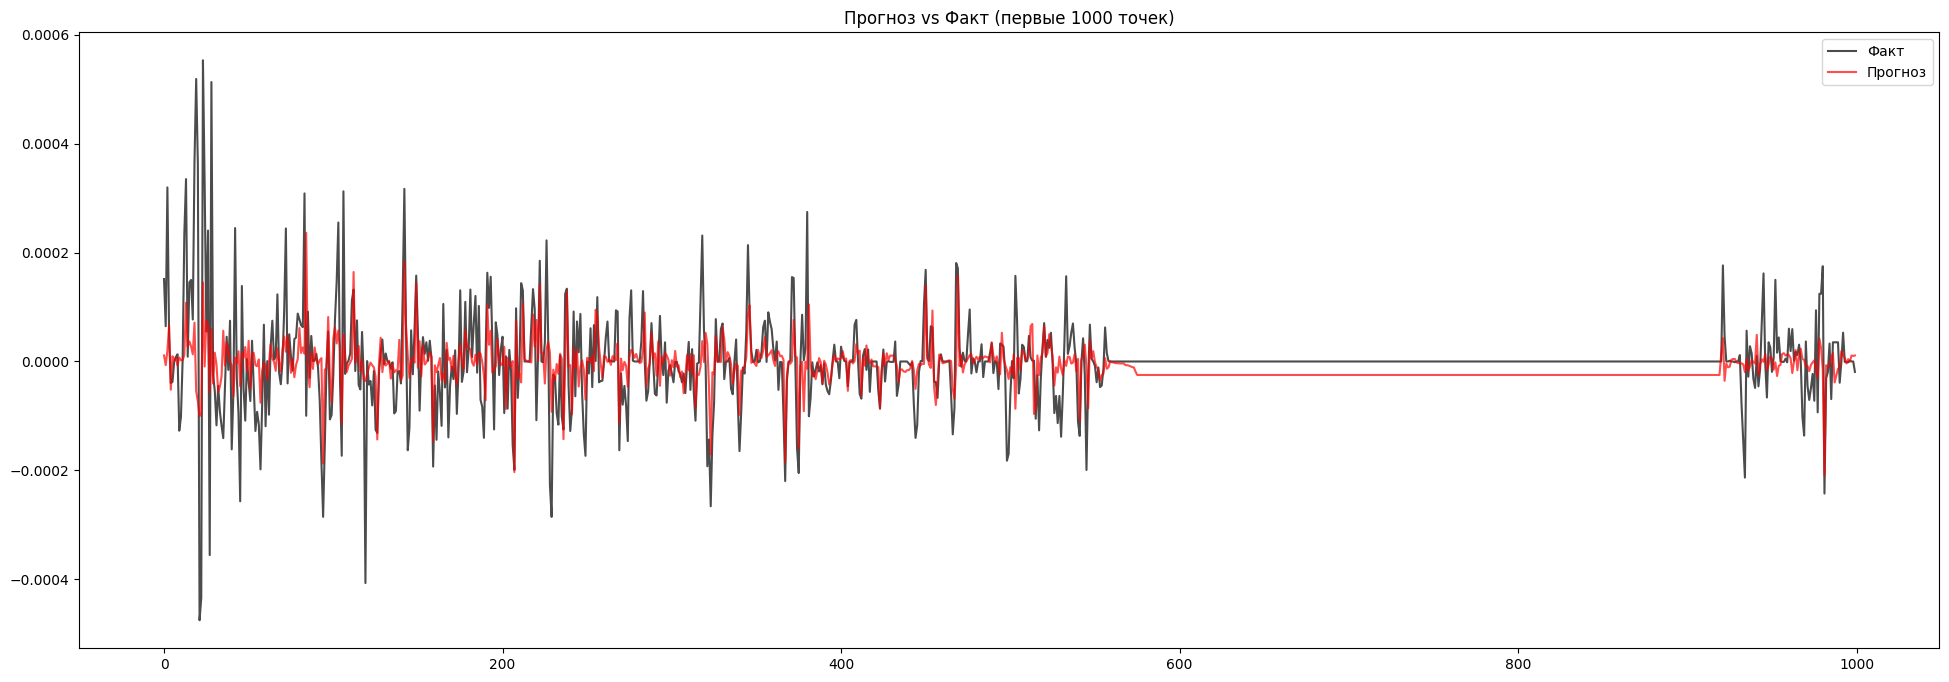

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=8,
)

Обучение модели...
[0]	validation_0-rmse:0.00020
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[750]	validation_0-rmse:0.00015
[800]	validation_0-rmse:0.00015
[850]	validation_0-rmse:0.00015
[900]	validation_0-rmse:0.00015
[915]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000100
RMSE                     : 0.000150
R²                       : 0.380152
MAE / mean|Δ|            : 0.602214
RMSE / RMSE_base         : 0.592601
mean|Δ| (target)         : 0.000167

------------------------------------------------------------
Directional Accuracy     : 0.888510
Target Pos Ratio         : 0.888510
Profit Factor            : 41222361471.573425
Avg Gain (correct)       : 0.000187
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8873, 0.8898)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
           quantile  confidence  directional_acc  mean_return  n_samples
 (0.000327, 0.0022]    0.000445         0.999758     0.000437      24752
(0.00024, 0.000327]    0.000279         0.996364     0.000276      24752
(0.000195, 0.00024]    0.000217         0.983557     0.000212      24

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


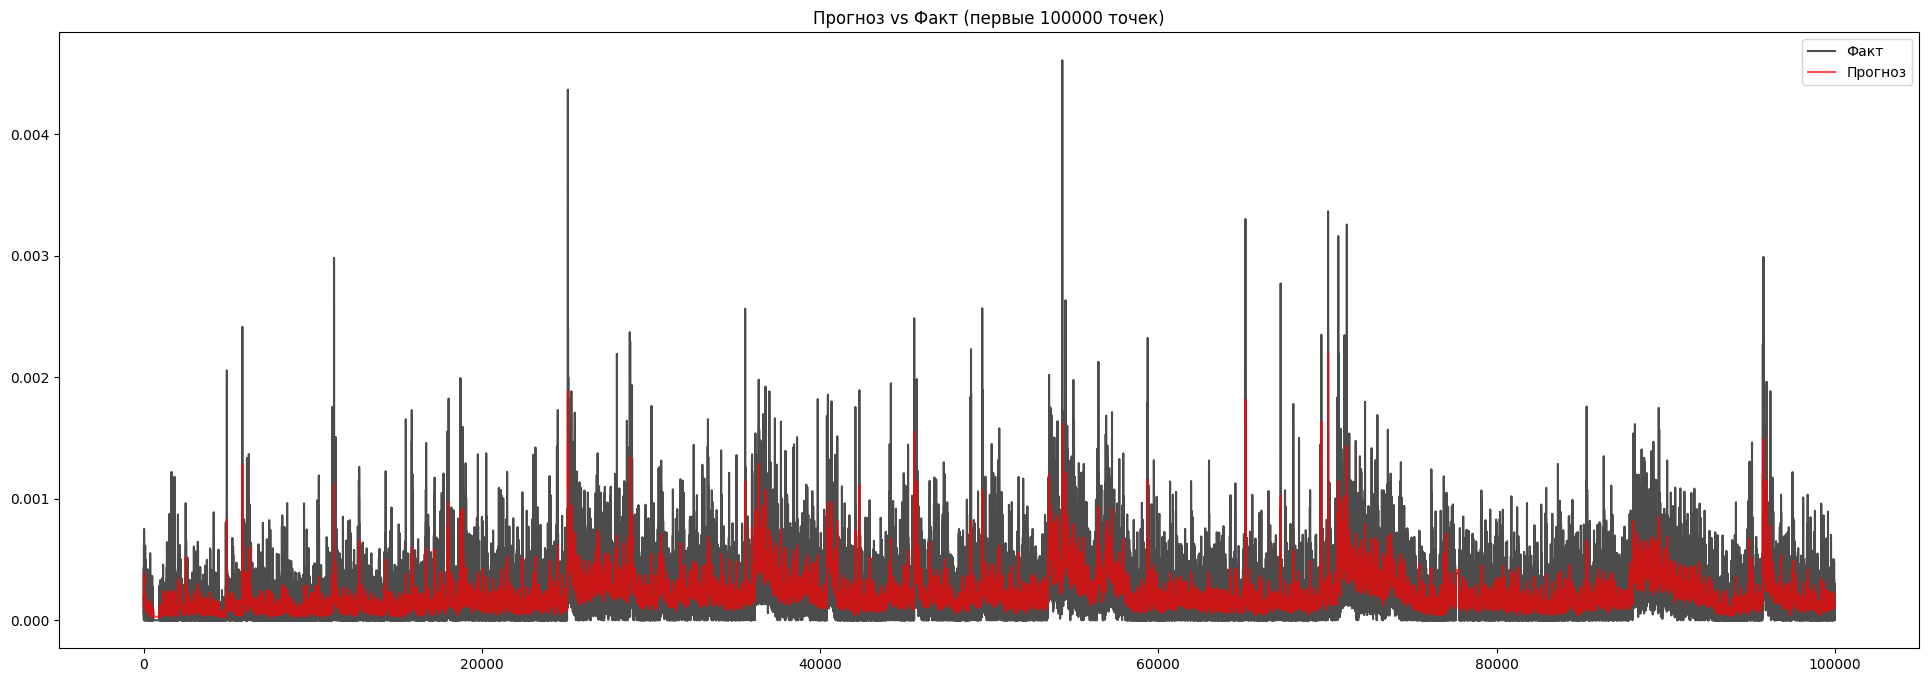

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)